# 01 - ERA5-Land climate features (Version A and Version B)

For every spring: the 15-year mean and Mann-Kendall Sen's slope of 2 m temperature, 2 m dewpoint,
total precipitation (mm/yr) and potential evaporation (mm/yr, positive), from the nearest
ERA5-Land 0.1 deg cell.

* **Version A** (label-conditional): active springs use 2009-2023; dried springs use the 15 years
  ending at their own drying year. This leaks the label and is kept only to document Models 1-2.
* **Version B** (fixed): every spring uses 2009-2023 (the survey year is 2023).

In [1]:
import sys, json, pathlib
sys.path.insert(0, str(pathlib.Path.cwd().parent / "src"))  # run from notebooks/

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from spring_drying.config import (FIGURES_DIR, TABLES_DIR, RANDOM_STATE, WINDOW_END, WINDOW_LEN,
                                  SURVEY_YEAR, ERA5_LAND_FIRST_YEAR, RAW_SURVEY_PATH, NC_PATH)
from spring_drying.data import load_springs, attach_drying_reason

sns.set_style("whitegrid")
pd.set_option("display.width", 140)

def save_json(obj, name):
    def conv(o):
        if isinstance(o, (np.integer,)): return int(o)
        if isinstance(o, (np.floating,)): return float(o)
        if isinstance(o, (np.ndarray,)): return o.tolist()
        raise TypeError(type(o))
    with open(TABLES_DIR / name, "w", encoding="utf-8") as f:
        json.dump(obj, f, indent=2, default=conv)
    print("saved", TABLES_DIR / name)

In [2]:
import xarray as xr
from spring_drying.climate import (FEATURE_COLS, cell_annual_series, fixed_window_features,
                                   label_conditional_features, grid_cell_ids)

springs = load_springs()
lat, lon = springs["Latitude"].values, springs["Longitude"].values
with xr.open_dataset(NC_PATH) as ds:
    era5 = {"lat_res": float(abs(ds.latitude.values[1] - ds.latitude.values[0])),
            "first_month": str(pd.Timestamp(ds.valid_time.values[0]).date()),
            "last_month": str(pd.Timestamp(ds.valid_time.values[-1]).date()),
            "n_months": int(ds.sizes["valid_time"]), "variables": list(ds.data_vars),
            "lat_min": float(ds.latitude.min()), "lat_max": float(ds.latitude.max()),
            "lon_min": float(ds.longitude.min()), "lon_max": float(ds.longitude.max())}
era5

{'lat_res': 0.10000000000000142,
 'first_month': '1950-01-01',
 'last_month': '2026-04-01',
 'n_months': 916,
 'variables': ['d2m', 't2m', 'pev', 'tp'],
 'lat_min': 0.0,
 'lat_max': 40.0,
 'lon_min': 60.0,
 'lon_max': 100.0}

In [3]:
version_a = label_conditional_features(lat, lon, springs["dried"].values, springs["dried_year"].values)
version_b = fixed_window_features(lat, lon)
version_a.to_csv(TABLES_DIR / "climate_features_version_a.csv", index=False)
version_b.to_csv(TABLES_DIR / "climate_features_version_b.csv", index=False)

dried = springs["dried"] == 1
missing_year = dried & springs["dried_year"].isna()
too_early = dried & (springs["dried_year"] < ERA5_LAND_FIRST_YEAR + WINDOW_LEN - 1)
facts = {"era5": era5, "window": f"{WINDOW_END - WINDOW_LEN + 1}-{WINDOW_END}",
         "version_a_valid_rows": int(version_a.notna().all(axis=1).sum()),
         "version_a_missing_year": int(missing_year.sum()), "version_a_too_early": int(too_early.sum()),
         "n_cells": int(len(np.unique(grid_cell_ids(lat, lon)))),
         "version_b_distinct_vectors": int(version_b.round(9).drop_duplicates().shape[0]),
         "version_a_distinct_vectors": int(version_a.dropna().round(9).drop_duplicates().shape[0])}
facts

{'era5': {'lat_res': 0.10000000000000142,
  'first_month': '1950-01-01',
  'last_month': '2026-04-01',
  'n_months': 916,
  'variables': ['d2m', 't2m', 'pev', 'tp'],
  'lat_min': 0.0,
  'lat_max': 40.0,
  'lon_min': 60.0,
  'lon_max': 100.0},
 'window': '2009-2023',
 'version_a_valid_rows': 3278,
 'version_a_missing_year': 4,
 'version_a_too_early': 5,
 'n_cells': 12,
 'version_b_distinct_vectors': 12,
 'version_a_distinct_vectors': 136}

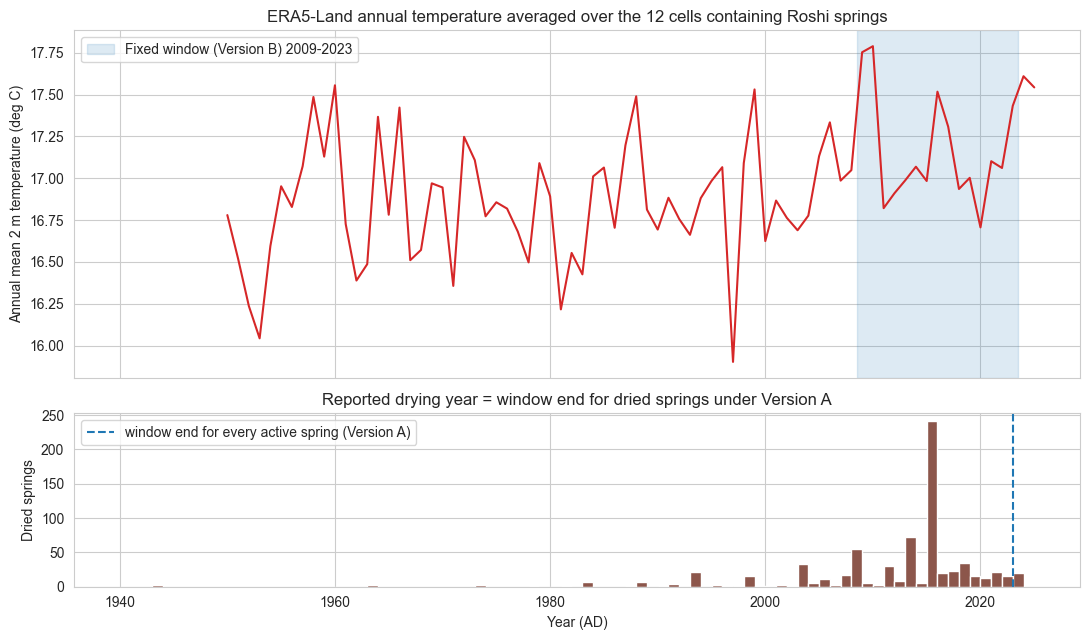

0.3680802239312122

In [4]:
annual, cells = cell_annual_series(lat, lon)
regional = annual.groupby(level="year").mean()
fig, axes = plt.subplots(2, 1, figsize=(11, 6.5), sharex=True, gridspec_kw={"height_ratios": [2, 1]})
axes[0].plot(regional.index, regional["t2m"], color="#d62728")
axes[0].axvspan(WINDOW_END - WINDOW_LEN + 0.5, WINDOW_END + 0.5, color="#1f77b4", alpha=0.15,
                label=f"Fixed window (Version B) {WINDOW_END - WINDOW_LEN + 1}-{WINDOW_END}")
axes[0].set_ylabel("Annual mean 2 m temperature (deg C)")
axes[0].set_title("ERA5-Land annual temperature averaged over the 12 cells containing Roshi springs")
axes[0].legend(loc="upper left")
dy = springs.loc[dried, "dried_year"].dropna()
axes[1].hist(dy, bins=np.arange(1940, 2025), color="#8c564b")
axes[1].axvline(WINDOW_END, color="#1f77b4", ls="--", lw=1.5, label="window end for every active spring (Version A)")
axes[1].set_ylabel("Dried springs"); axes[1].set_xlabel("Year (AD)"); axes[1].legend(loc="upper left")
axes[1].set_title("Reported drying year = window end for dried springs under Version A")
plt.tight_layout(); plt.savefig(FIGURES_DIR / "climate_timeseries_windows.png", dpi=300); plt.show()
facts["warming_1950s_to_2010s"] = float(regional.loc[2010:2019, "t2m"].mean() - regional.loc[1950:1959, "t2m"].mean())
facts["warming_1950s_to_2010s"]

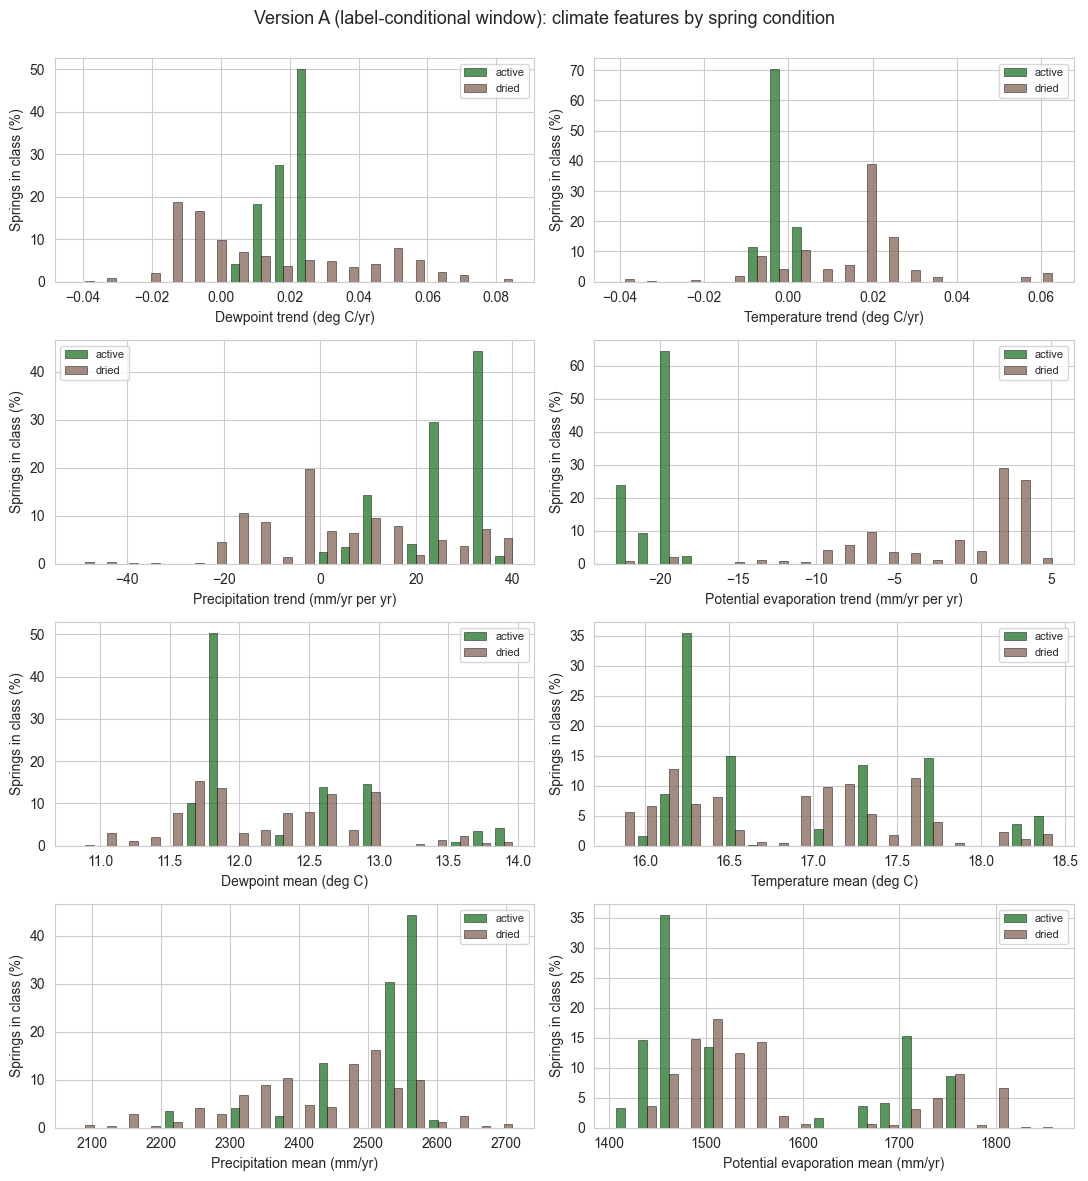

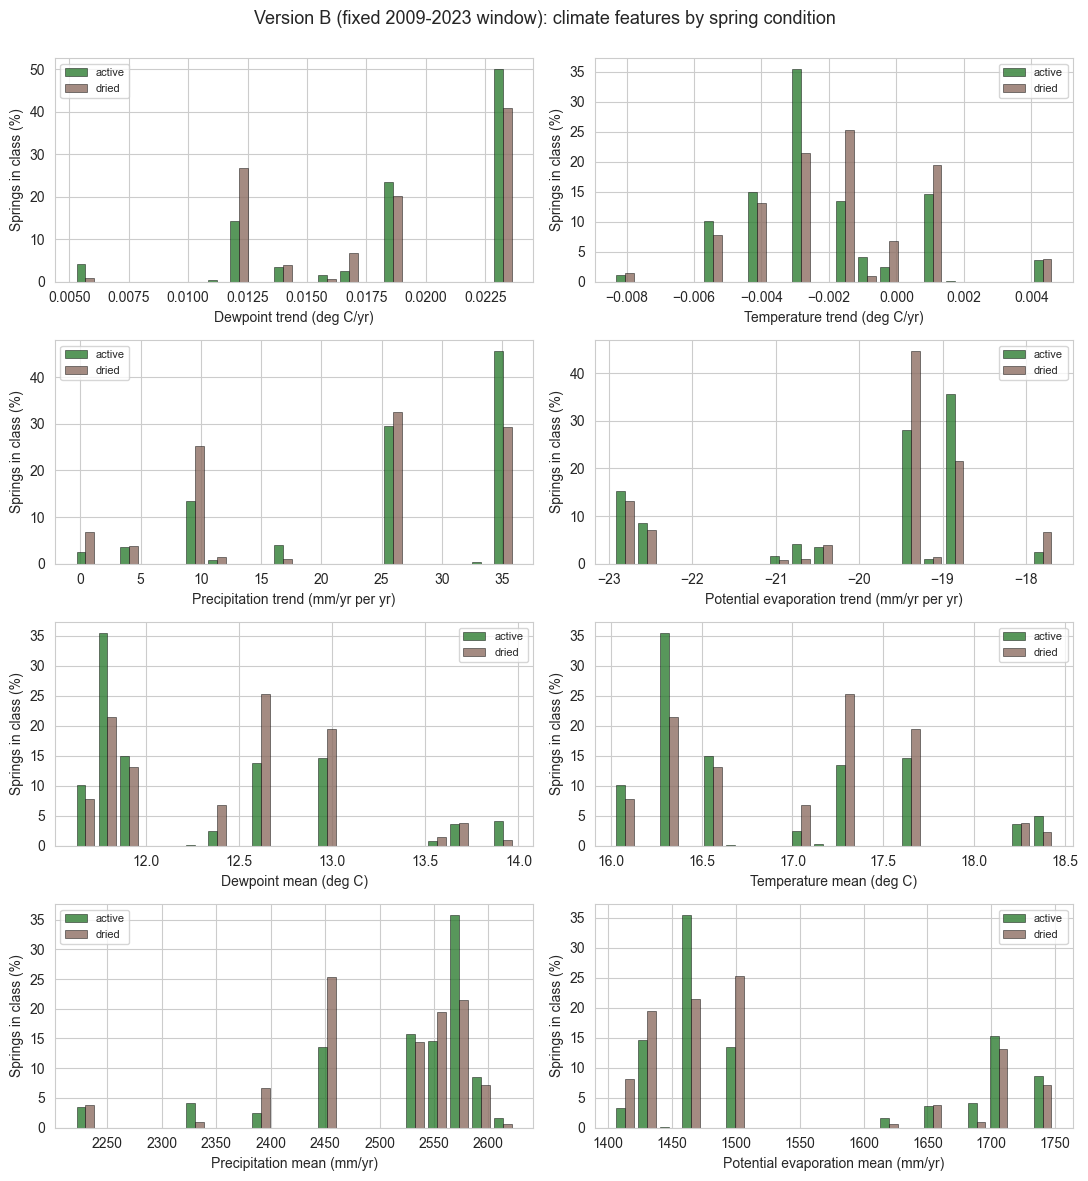

,medians_version_a,medians_version_b
Dewpoint_rate_active,0.023159,0.023159
Dewpoint_rate_dried,0.004708,0.018453
Temperature_rate_active,-0.002819,-0.002819
Temperature_rate_dried,0.018984,-0.001646
Precipitation_rate_active,25.304232,25.304232
Precipitation_rate_dried,0.907168,25.195524
Evaporation_rate_active,-19.252091,-19.252091
Evaporation_rate_dried,1.615121,-19.257907
Dewpoint_mean_active,11.919495,11.919495
Dewpoint_mean_dried,12.244780,12.668616


In [5]:
LABELS = {"Dewpoint_rate": "Dewpoint trend (deg C/yr)", "Temperature_rate": "Temperature trend (deg C/yr)",
          "Precipitation_rate": "Precipitation trend (mm/yr per yr)", "Evaporation_rate": "Potential evaporation trend (mm/yr per yr)",
          "Dewpoint_mean": "Dewpoint mean (deg C)", "Temperature_mean": "Temperature mean (deg C)",
          "Precipitation_mean": "Precipitation mean (mm/yr)", "Evaporation_mean": "Potential evaporation mean (mm/yr)"}

def plot_distributions(feat, title, fname):
    fig, axes = plt.subplots(4, 2, figsize=(11, 12)); axes = axes.ravel()
    for ax, col in zip(axes, FEATURE_COLS):
        valid = feat[col].notna()
        edges = np.histogram_bin_edges(feat.loc[valid, col], bins=20)
        width = (edges[1] - edges[0]) * 0.4
        for off, (c, color) in zip((-0.5, 0.5), (("active", "#2E7D32"), ("dried", "#8D6E63"))):
            vals = feat.loc[valid & ((springs["dried"] == 1) == (c == "dried")), col]
            counts, _ = np.histogram(vals, bins=edges)
            ax.bar((edges[:-1] + edges[1:]) / 2 + off * width, 100 * counts / len(vals), width=width,
                   color=color, alpha=0.8, label=c, edgecolor="black", linewidth=0.4)
        ax.set_xlabel(LABELS[col]); ax.set_ylabel("Springs in class (%)"); ax.legend(fontsize=8)
    fig.suptitle(title, fontsize=13)
    plt.tight_layout(rect=[0, 0, 1, 0.98]); plt.savefig(FIGURES_DIR / fname, dpi=300); plt.show()

plot_distributions(version_a, "Version A (label-conditional window): climate features by spring condition",
                   "climate_distribution_version_a.png")
plot_distributions(version_b, f"Version B (fixed {WINDOW_END - WINDOW_LEN + 1}-{WINDOW_END} window): climate features by spring condition",
                   "climate_distribution_version_b.png")

def medians(feat):
    return {c: {"active": float(feat.loc[springs["dried"] == 0, c].median()),
                "dried": float(feat.loc[springs["dried"] == 1, c].median())} for c in FEATURE_COLS}
facts["medians_version_a"] = medians(version_a)
facts["medians_version_b"] = medians(version_b)
pd.DataFrame({k: {f"{c}_{g}": v for c, d in facts[k].items() for g, v in d.items()} for k in ["medians_version_a", "medians_version_b"]})

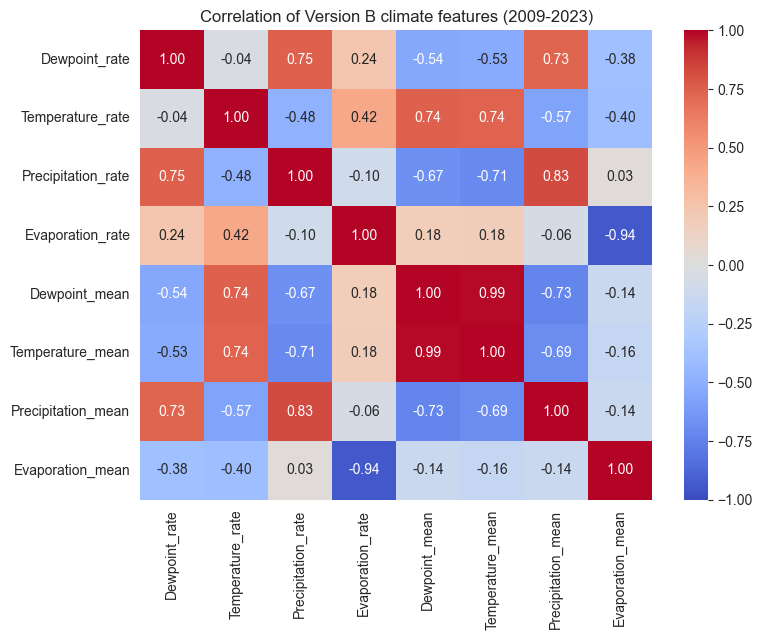

saved C:\Users\kants\OneDrive\Desktop\ME Classes\3rd Sem\Thesis & Project\Python program\results\tables\climate_facts.json


In [6]:
corr = version_b.corr()
plt.figure(figsize=(8, 6.5))
sns.heatmap(corr, annot=True, fmt=".2f", cmap="coolwarm", center=0, vmin=-1, vmax=1)
plt.title(f"Correlation of Version B climate features ({WINDOW_END - WINDOW_LEN + 1}-{WINDOW_END})")
plt.tight_layout(); plt.savefig(FIGURES_DIR / "climate_correlation_version_b.png", dpi=300); plt.show()
save_json(facts, "climate_facts.json")